## Diabetes Prediction Challenge -Análise Exploratoria dos Dados
### Contexto
Este notebook apresenta uma Análise Exploratória de Dados (EDA) para o Diabetes Prediction Challenge. O conjunto de dados foi gerado sinteticamente a partir de um modelo de Deep Learning treinado sobre o Diabetes Health Indicators Dataset. O desafio consiste em prever a probabilidade de um indivíduo ser diagnosticado com diabetes (diagnosed_diabetes) com base em indicadores de saúde, hábitos de vida e histórico clínico.

A análise aqui conduzida visa compreender a fidelidade dos dados sintéticos, avaliar a qualidade das informações e identificar as variáveis de maior poder preditivo, servindo como base técnica para as etapas de engenharia de atributos e modelagem.

### Objetivos
* Auditoria de Dados: Avaliar a integridade do dataset (700.000 registros), tipos de variáveis e presença de valores ausentes ou inconsistentes.
* Análise de Diagnóstico: Investigar as distribuições univariadas e o comportamento da variável alvo diagnosed_diabetes
* Identificação de Padrões: Explorar relações bivariadas e multivariadas (ex: correlação entre IMC, idade e marcadores lipídicos) que possam orientar a criação de variáveis derivadas e a estratégia de pré-processamento.


In [1]:
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.patches as mpatches


from setup_notebook import setup_path
setup_path()
from src.functions import *


from matplotlib.colors import LinearSegmentedColormap
import warnings

warnings.filterwarnings("ignore")

color_palette21 = [
    "#004C4C", "#006666", "#008080", "#199191", "#29A3A3",
    "#40B5B5", "#55C7C7", "#66D9D9", "#80ECEC", "#99FFFF", 
    "#FFD580", "#FFC460", "#FFB240", "#FFA020", "#FF8E00",
    "#FF7C00", "#FF6400", "#FF4C00", "#FF3300", "#FF1A00", "#FF0000"]

# Definir cores
color_binary = {
    0: color_palette21[-7],  # Vermelho para não sobreviveu
    1: color_palette21[3]   # Azul para sobreviveu
}

sns.set_palette(sns.color_palette(color_palette21))
sns.color_palette(color_palette21)

[(0.0, 0.2980392156862745, 0.2980392156862745),
 (0.0, 0.4, 0.4),
 (0.0, 0.5019607843137255, 0.5019607843137255),
 (0.09803921568627451, 0.5686274509803921, 0.5686274509803921),
 (0.1607843137254902, 0.6392156862745098, 0.6392156862745098),
 (0.25098039215686274, 0.7098039215686275, 0.7098039215686275),
 (0.3333333333333333, 0.7803921568627451, 0.7803921568627451),
 (0.4, 0.8509803921568627, 0.8509803921568627),
 (0.5019607843137255, 0.9254901960784314, 0.9254901960784314),
 (0.6, 1.0, 1.0),
 (1.0, 0.8352941176470589, 0.5019607843137255),
 (1.0, 0.7686274509803922, 0.3764705882352941),
 (1.0, 0.6980392156862745, 0.25098039215686274),
 (1.0, 0.6274509803921569, 0.12549019607843137),
 (1.0, 0.5568627450980392, 0.0),
 (1.0, 0.48627450980392156, 0.0),
 (1.0, 0.39215686274509803, 0.0),
 (1.0, 0.2980392156862745, 0.0),
 (1.0, 0.2, 0.0),
 (1.0, 0.10196078431372549, 0.0),
 (1.0, 0.0, 0.0)]

---
## 2. Dataload & Pré-visualização dos Dados


In [2]:
# 2-Dataload & Pré-visualização dos Dados
dfo = pd.read_csv("/home/akel/PycharmProjects/Kaggle/Diabetes_Prediction_Challenge/data/raw/train.csv")
df=dfo.drop(columns='id')
NC=df.shape[1]
display(df.head(5))
inital_describe(df)

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


📊 ANÁLISE EXPLORATÓRIA DO DATAFRAME

📈 DIMENSÕES DO DATASET:
   • 700000 linhas
   • 25 colunas
   • Total de células: 17500000

🔧 TIPOS DE DADOS:
   • int64: 13 colunas
   • float64: 6 colunas
   • object: 6 colunas

📋 DETALHAMENTO DOS TIPOS POR COLUNA:
                                       Tipo
age                                   int64
alcohol_consumption_per_week          int64
physical_activity_minutes_per_week    int64
diet_score                          float64
sleep_hours_per_day                 float64
screen_time_hours_per_day           float64
bmi                                 float64
waist_to_hip_ratio                  float64
systolic_bp                           int64
diastolic_bp                          int64
heart_rate                            int64
cholesterol_total                     int64
hdl_cholesterol                       int64
ldl_cholesterol                       int64
triglycerides                         int64
gender                               obje

,count,mean,std,min,25%,50%,75%,max
age,700000.0,50.359734,11.655520,19.00,42.00,50.00,58.00,89.00
alcohol_consumption_per_week,700000.0,2.072411,1.048189,1.00,1.00,2.00,3.00,9.00
physical_activity_minutes_per_week,700000.0,80.230803,51.195071,1.00,49.00,71.00,96.00,747.00
diet_score,700000.0,5.963695,1.463336,0.10,5.00,6.00,7.00,9.90
sleep_hours_per_day,700000.0,7.002200,0.901907,3.10,6.40,7.00,7.60,9.90
screen_time_hours_per_day,700000.0,6.012733,2.022707,0.60,4.60,6.00,7.40,16.50
bmi,700000.0,25.874684,2.860705,15.10,23.90,25.90,27.80,38.40
waist_to_hip_ratio,700000.0,0.858766,0.037980,0.68,0.83,0.86,0.88,1.05
systolic_bp,700000.0,116.294193,11.010390,91.00,108.00,116.00,124.00,163.00
diastolic_bp,700000.0,75.440924,6.825775,51.00,71.00,75.00,80.00,104.00



✅ ANÁLISE CONCLUÍDA


### 2.1 Pré-visualização dos Dados


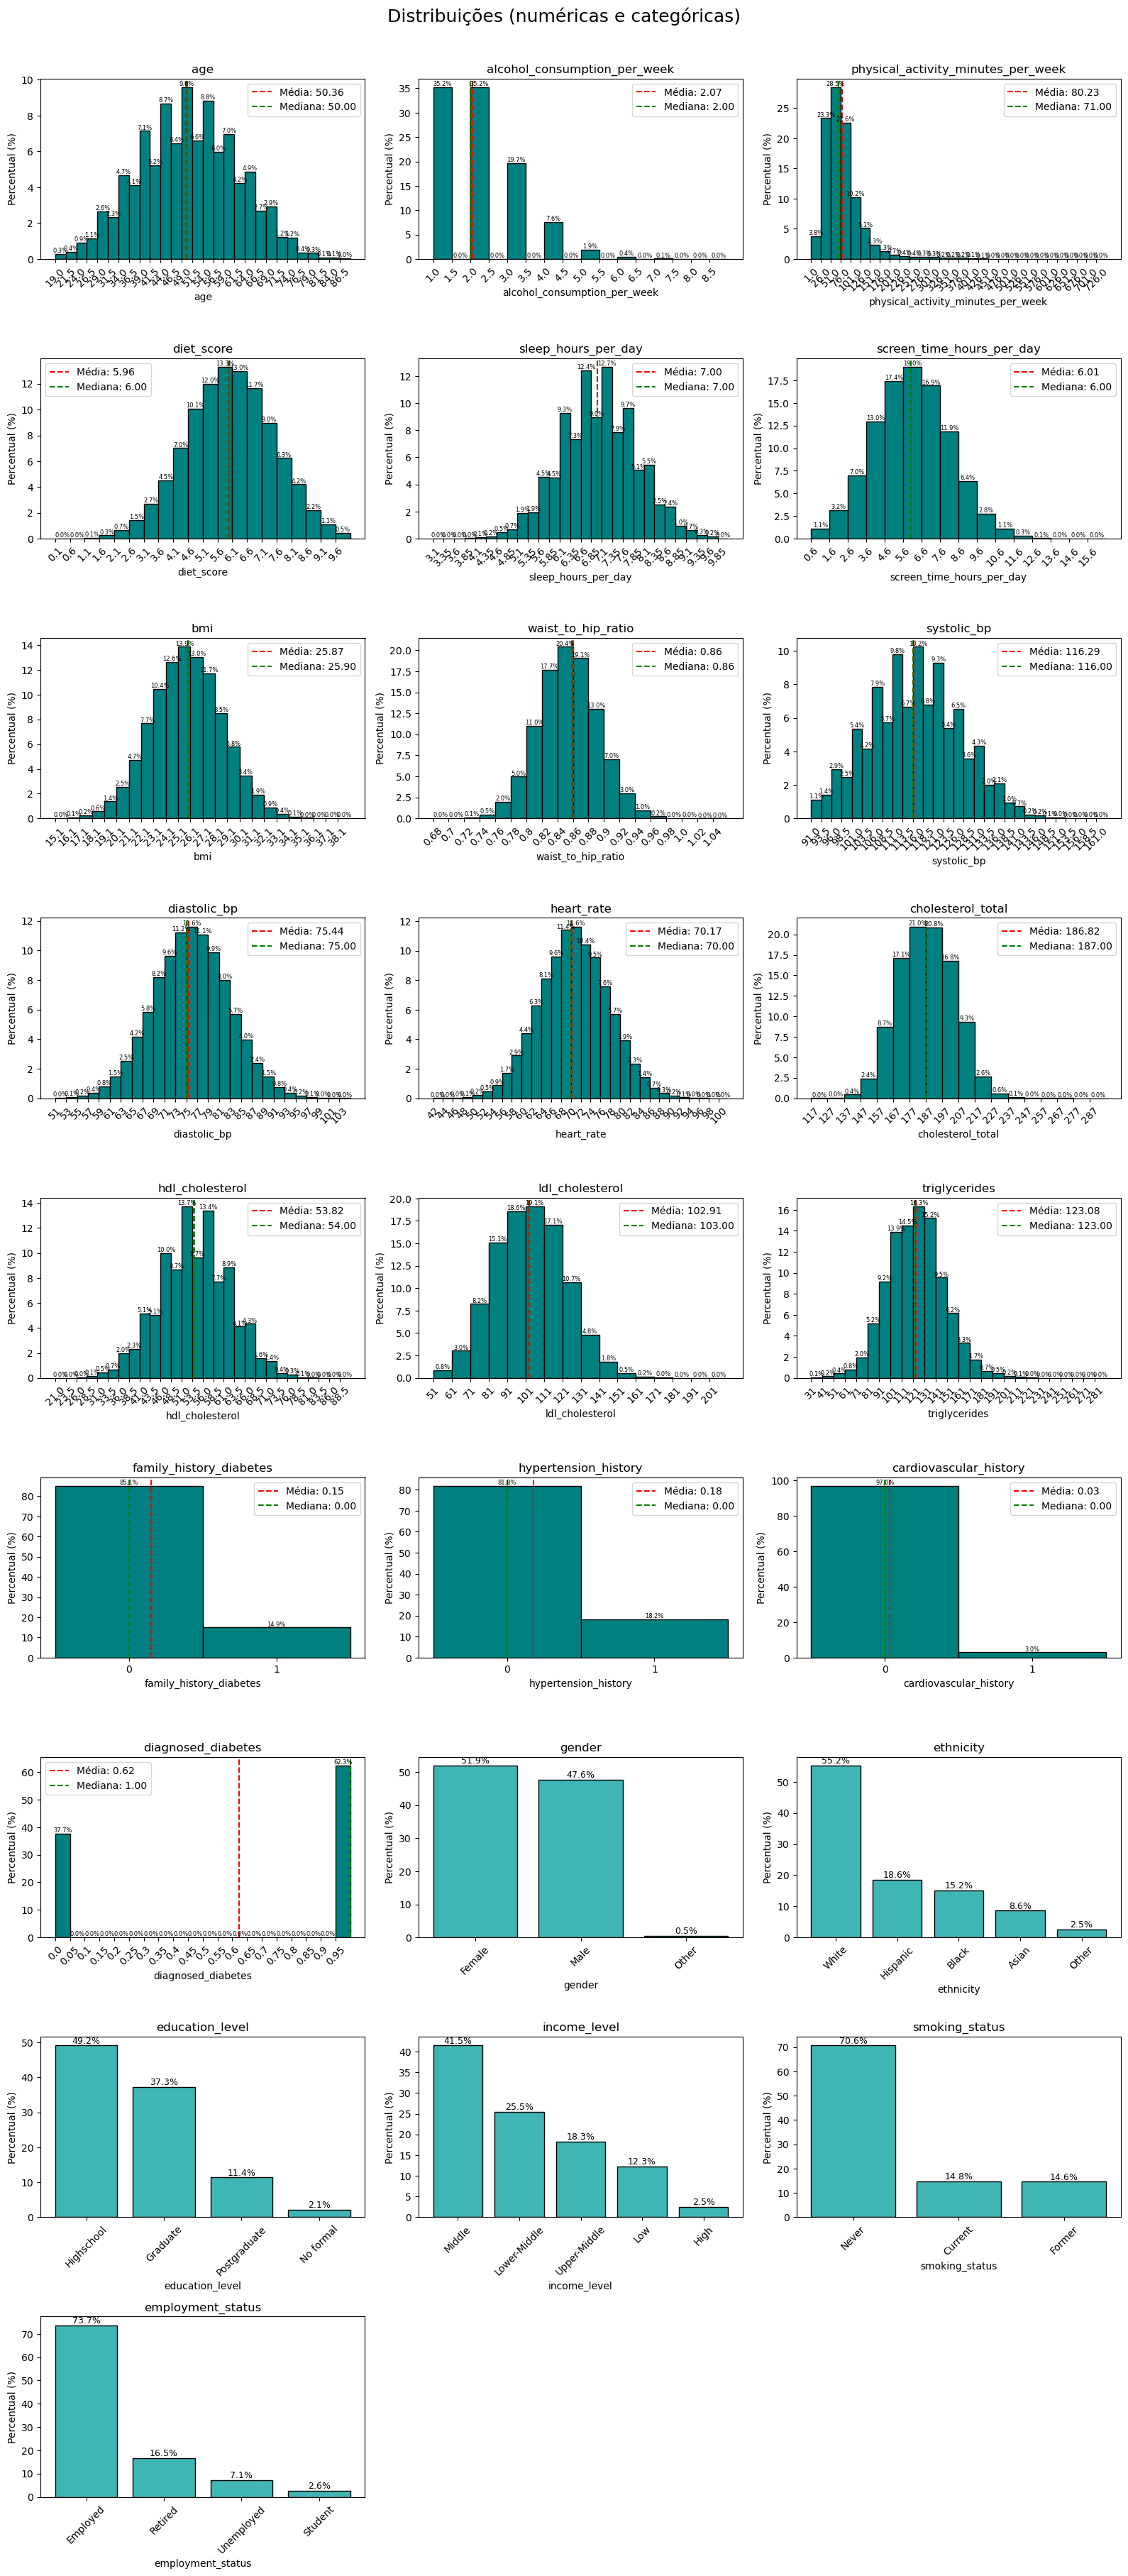

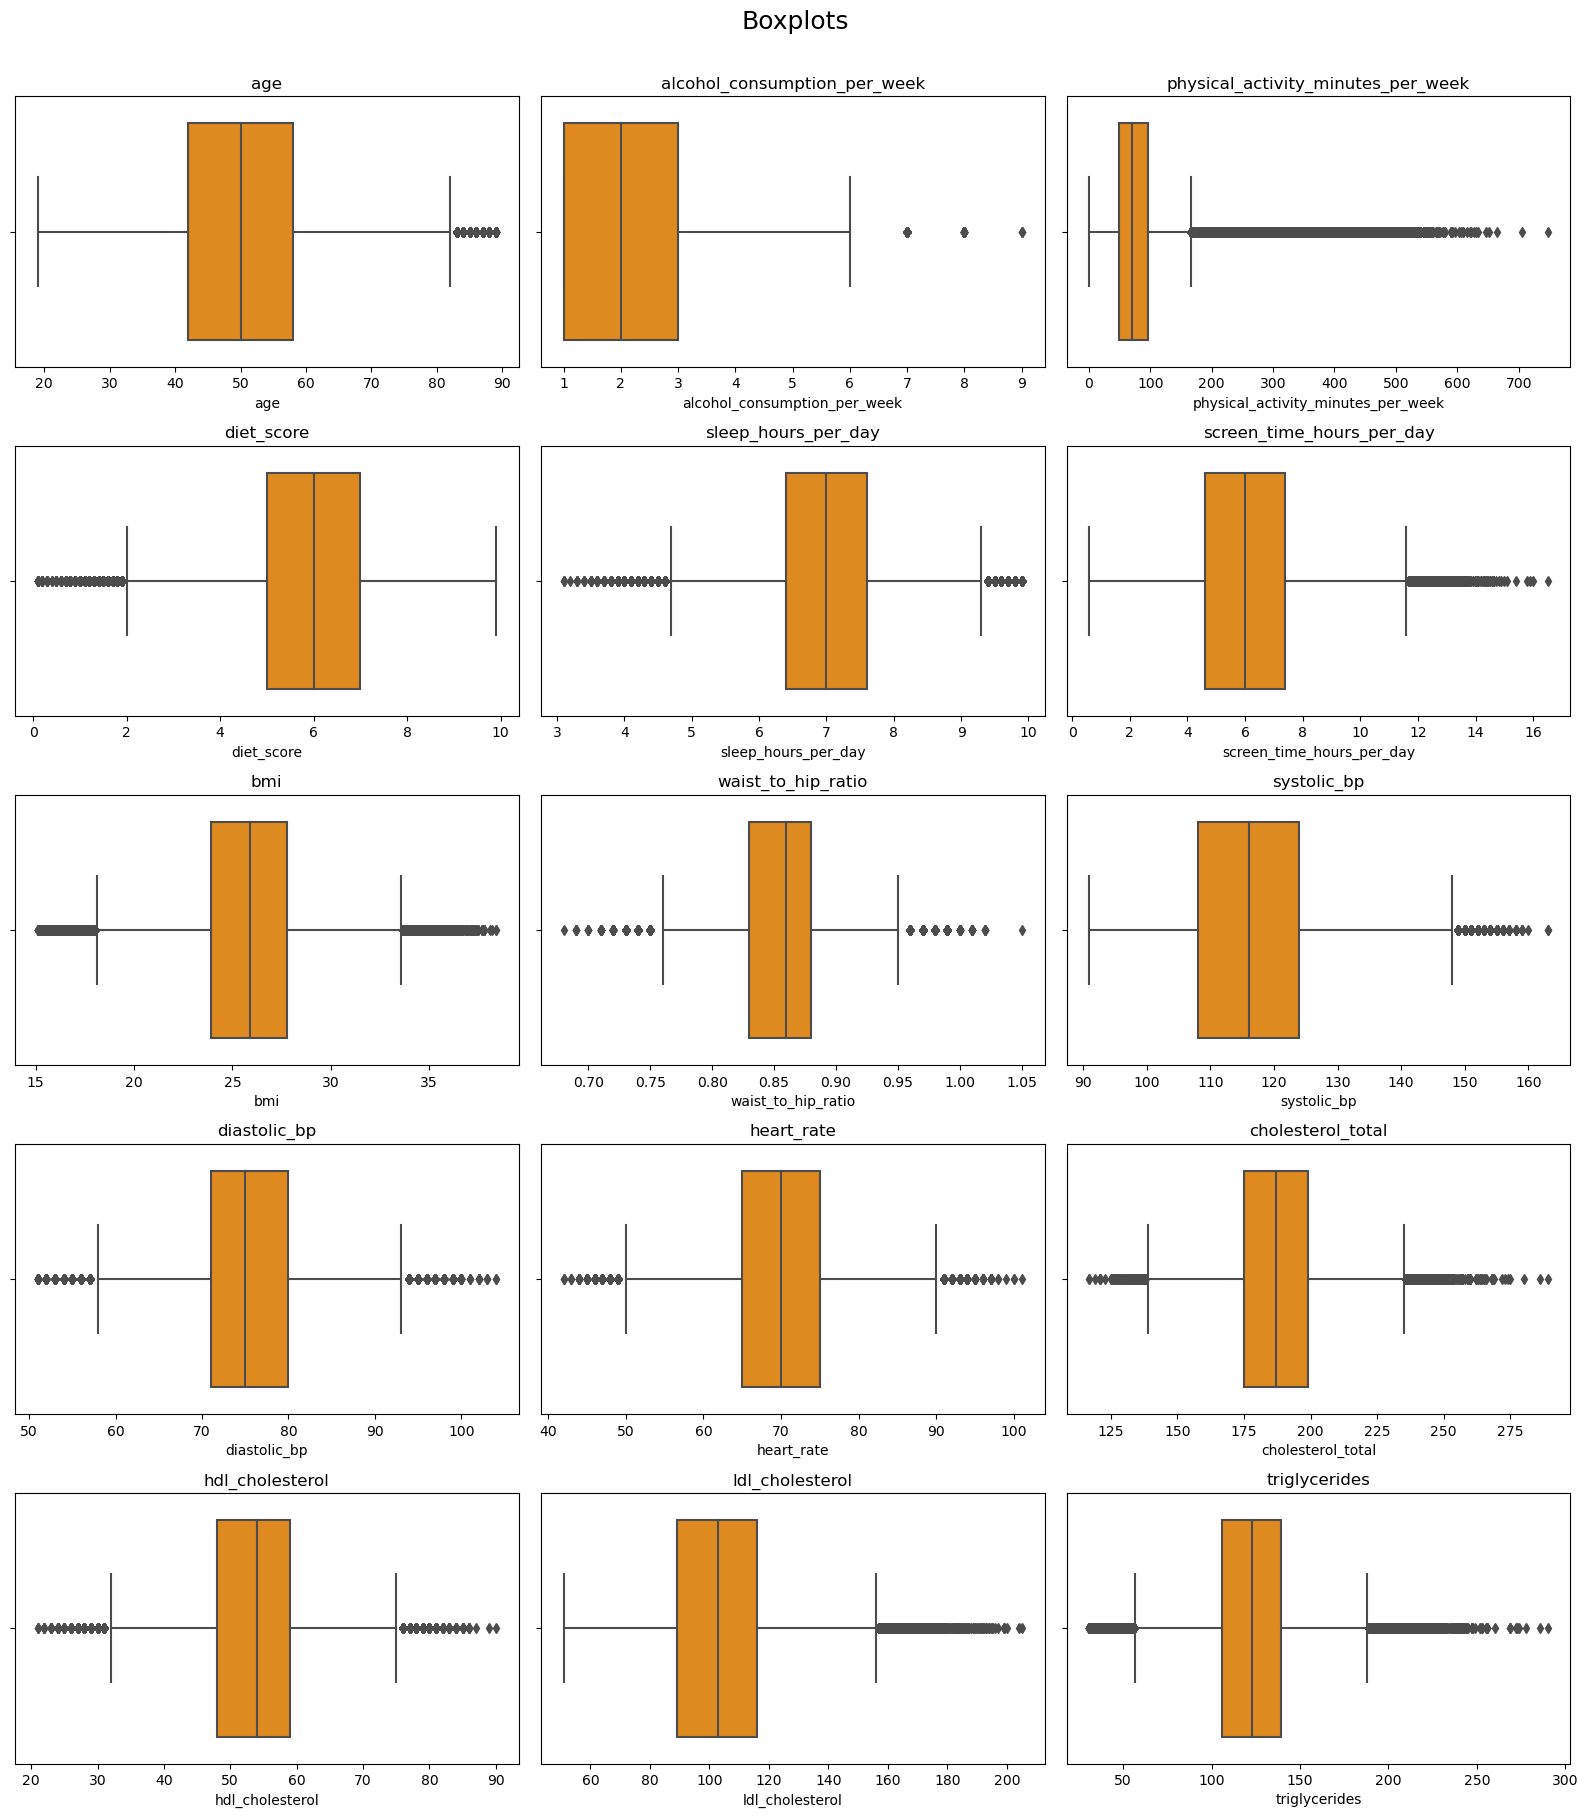

In [3]:
out_1=mult_plt2(df,ncols=3,max_bins=30,figsize=(16,36))
out_2=mult_plt2(df,'box',max_bins=20,figsize=(16, 18))


## 3.Pré-processamento de Dados
### 3.1 remoção de outliers

In [4]:
#df_filt=remove_outliers_iqr(df,['diagnosed_diabetes','family_history_diabetes','hypertension_history','cardiovascular_history'],10)
df_filt=df

## 4 Engenharia de features
### 4.1 Age Group e PAW_Group
Criação das features `AGE_group` e `PAW_Group`
* **PAW**: physical_activity_minutes_per_wee


In [5]:
df_filt['Age_Group'] = pd.cut(
    df_filt['age'],
    bins=[18, 29, 44, 59, 69, 79, np.inf],
    labels=[
        'Jovem Adulto (18–29)',
        'Adulto (30–44)',
        'Meia-idade (45–59)',
        'Idoso Jovem (60–69)',
        'Idoso (70–79)',
        'Idoso Muito Longevo (80+)'
    ],
    include_lowest=True
)

df_filt['PAW_Group'] = pd.cut(
    df_filt['physical_activity_minutes_per_week'],
    bins=[0, 29, 149, 299, np.inf],
    labels=[
        'Sedentário',
        'Baixo (<150)',
        'Recomendado (150-300)',
        'Alto (>300)'
    ],
    include_lowest=True
)

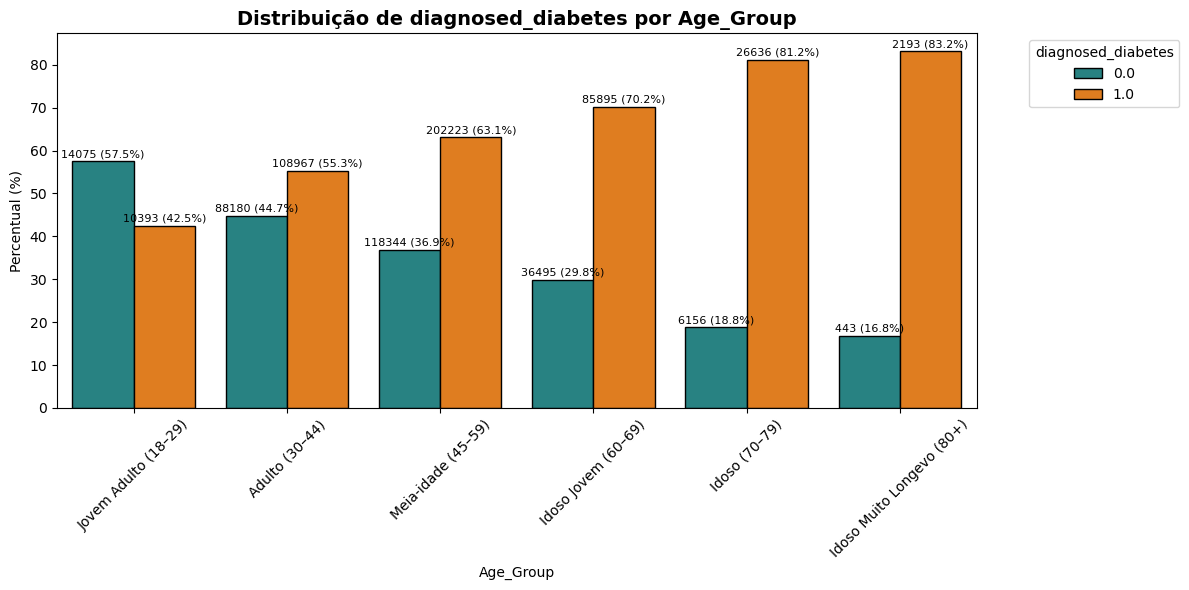

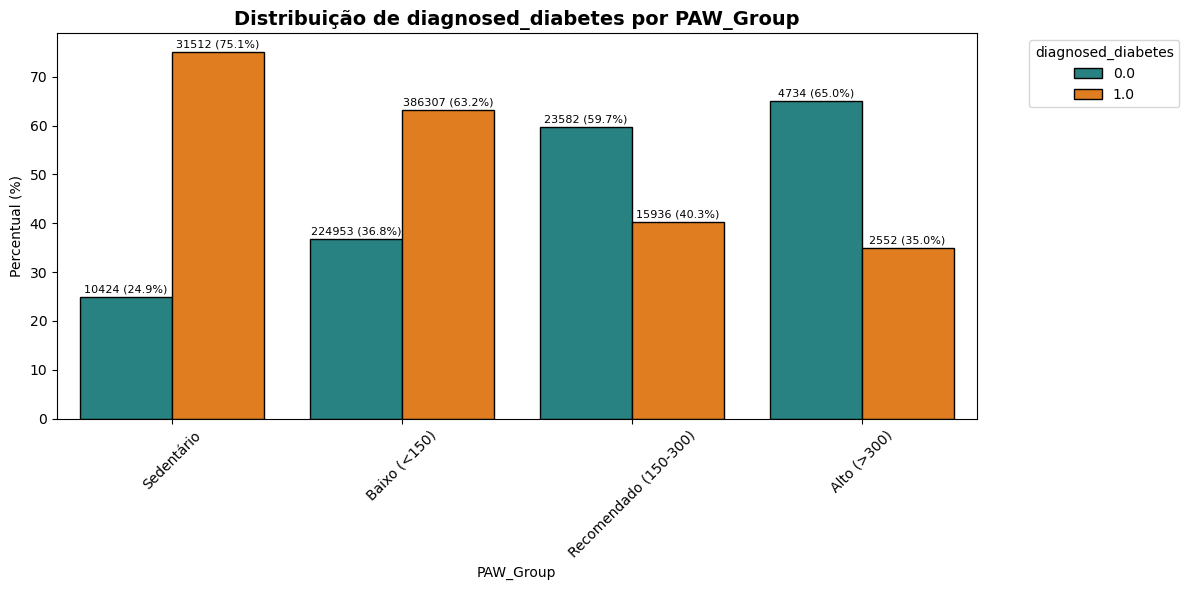

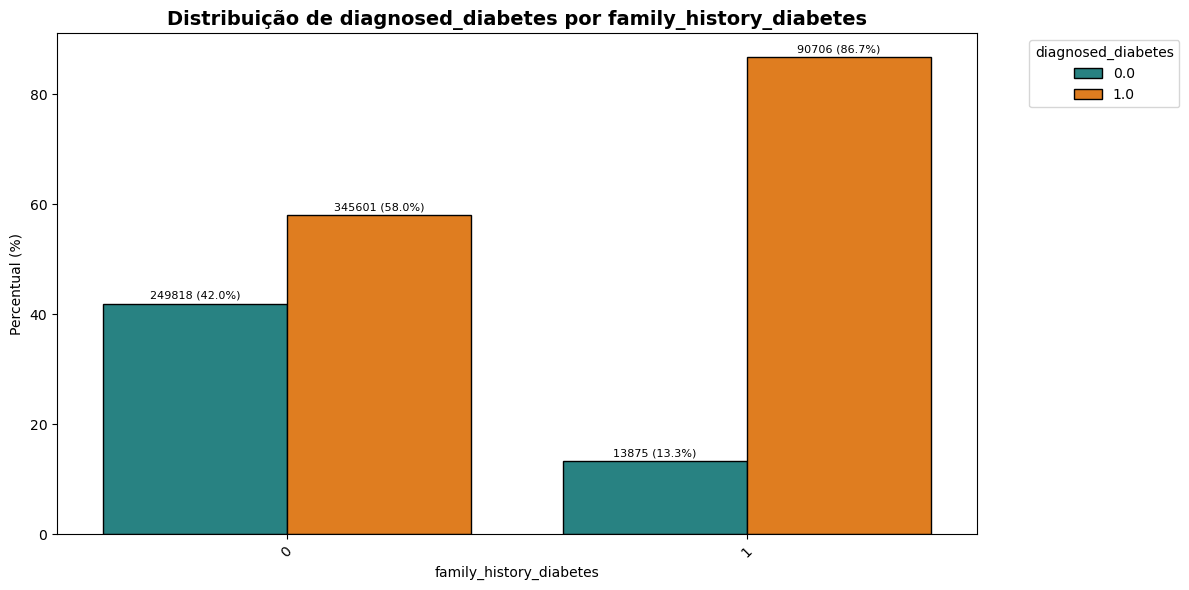


                   Diabéticos por grupos                    

                     👥 POR FAIXA ETÁRIA                     
Jovem Adulto (18–29)           42.48 %
Adulto (30–44)                 55.27 %
Meia-idade (45–59)             63.08 %
Idoso Jovem (60–69)            70.18 %
Idoso (70–79)                  81.23 %
Idoso Muito Longevo (80+)      83.19 %

             🏃‍♂️ POR NÍVEL DE ATIVIDADE FÍSICA             
Sedentário                     75.14 %
Baixo (<150)                   63.20 %
Recomendado (150-300)          40.33 %
Alto (>300)                    35.03 %

               👨‍👩‍👧‍👦 POR HISTÓRICO FAMILIAR               
0                              58.04 %
1                              86.73 %


In [6]:
stats1,stats2= bar_bar_cat(df_filt,'Age_Group','diagnosed_diabetes')
stats3,stats4= bar_bar_cat(df_filt,'PAW_Group','diagnosed_diabetes')
stats5,stats6= bar_bar_cat(df_filt,'family_history_diabetes','diagnosed_diabetes')

# Função para criar separadores
def print_header(texto,largura=60):
    print("\n" + "="*largura)
    print(f"{texto.center(largura)}")
    print("="*largura)


print_header(" Diabéticos por grupos ")

print_header("👥 POR FAIXA ETÁRIA")
for categoria, valor in stats2[1].items():
    print(f"{categoria:<30} {valor:.2f} %")
    
print_header("🏃‍♂️ POR NÍVEL DE ATIVIDADE FÍSICA")
for categoria, valor in stats4[1].items():
    print(f"{categoria:<30} {valor:.2f} %")

print_header("👨‍👩‍👧‍👦 POR HISTÓRICO FAMILIAR")
for categoria, valor in stats6[1].items():
    print(f"{categoria:<30} {valor:.2f} %")

### 4.2 Risco Probabilistico agrupado
`risk_age_p`,`risk_paw_p`,`risk_fh_p`,`global_prob_risk`

In [7]:
# Risco Probabilistico agrupado

target='diagnosed_diabetes'
age_prob  = stats2[1]/100   
paw_prob  = stats4[1]/100
fh_prob   = stats6[1]/100

# Executando o painel
# 1. Criando as colunas de risco individual (Target Encoding)
df_filt['risk_age_p'] = df_filt['Age_Group'].map(age_prob).astype(float).fillna(0.5)
df_filt['risk_paw_p'] = df_filt['PAW_Group'].map(paw_prob).astype(float).fillna(0.5)
df_filt['risk_fh_p'] = df_filt['family_history_diabetes'].map(fh_prob).astype(float).fillna(0.5)

# 2. O Score Probabilístico
# Calculamos a média das probabilidades 
df_filt['global_prob_risk'] = (df_filt['risk_age_p'] + df_filt['risk_paw_p'] +  df_filt['risk_fh_p']) / 3


### 4.3 Risco Probabilistico contínuo
Avaliando se diferentes transformações da feature  `physical_activity_minutes_per_week` afetam na sua correlação com a variavel alvo.

In [8]:
# Risco Probabilistico continuo
# Age: Quanto mais velho, maior o risco
min_age = df_filt['age'].min()
max_age = df_filt['age'].max()
# Normalizando para [0, 1]
df_filt['risk_age_cont'] = (df_filt['age'] - min_age) / (max_age - min_age)

#Normalizando para [0, 1] :max-min invertido
paw_min=df_filt['physical_activity_minutes_per_week'].min()
paw_max=df_filt['physical_activity_minutes_per_week'].max()
df_filt['risk_paw_cont'] = 1-( 
    (df_filt['physical_activity_minutes_per_week'] - paw_min) /
    (paw_max - paw_min))

#valores antigos (arbitrarios)
#w_age=0.35
#w_paw=0.15
#w_hf=0.50

#--------------------------------------------------------------------------
# Definindo o peso(W) do score
# Resolvendo sistema linear:  y = w1x1 + w2x2 + w3x3 +b
#                             W=inv(X'X)*X'y 

X = df_filt[['risk_age_cont', 'risk_paw_cont', 'family_history_diabetes']]
y = df_filt['diagnosed_diabetes']
X = np.c_[np.ones(X.shape[0]), X]
W, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
W_norm = W[1:]/W[1:].sum()

#--------------------------------------------------------------------------

w_age = W_norm[0]
w_paw = W_norm[1] 
w_hf  = W_norm[2] #
df_filt['continuous_risk_score'] = (
    (df_filt['risk_age_cont'] * w_age) + 
    (df_filt['risk_paw_cont'] * w_paw) + 
    (df_filt['family_history_diabetes'].astype(float) * w_hf))


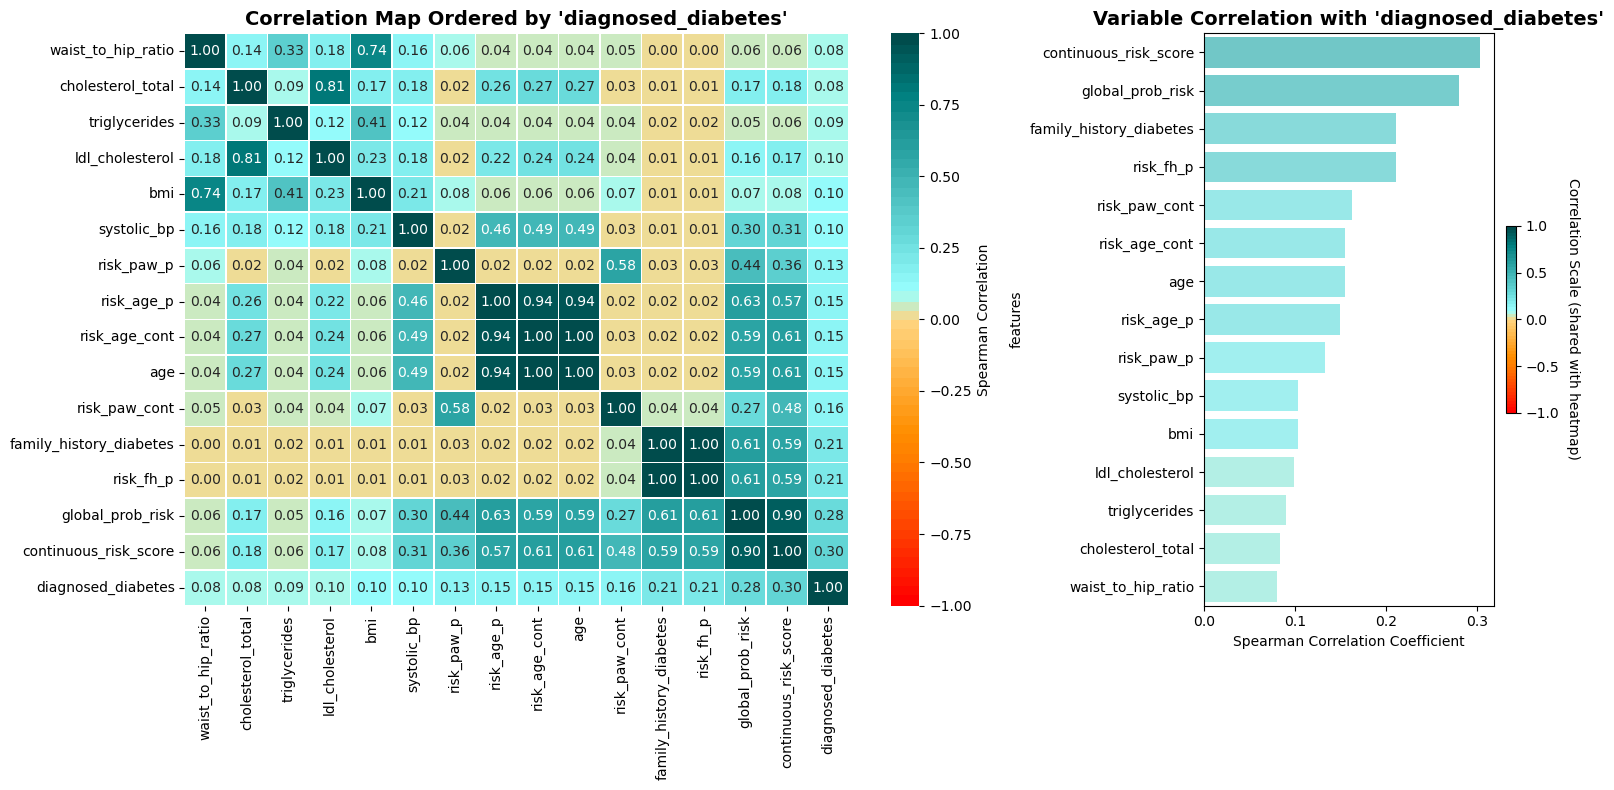


                    Correlacao c/ target                    
continuous_risk_score                  0.3035
global_prob_risk                       0.2807
family_history_diabetes                0.2111
risk_fh_p                              0.2111
risk_paw_cont                          0.1629
risk_age_cont                          0.1546
age                                    0.1546
risk_age_p                             0.1489
risk_paw_p                             0.1333
systolic_bp                            0.1037
bmi                                    0.1031
ldl_cholesterol                        0.0991
triglycerides                          0.0897
cholesterol_total                      0.0837
waist_to_hip_ratio                     0.0798
diastolic_bp                           0.0349
hypertension_history                   0.0300
cardiovascular_history                 0.0247
heart_rate                             0.0226
screen_time_hours_per_day              0.0182
alcohol_consumptio

In [9]:
corr,corr_tag=correlation_bar2(df_filt,'diagnosed_diabetes',metodo='spearman',top=15)
print_header("Correlacao c/ target")
for categoria, valor in corr_tag.items():
    print(f"{categoria:<36} { valor:>8.4f}")

In [10]:
df_filt[['age','physical_activity_minutes_per_week','Age_Group','global_prob_risk','continuous_risk_score','risk_age_cont', 'risk_paw_cont', 'family_history_diabetes']].head(8)

,age,physical_activity_minutes_per_week,Age_Group,global_prob_risk,continuous_risk_score,risk_age_cont,risk_paw_cont,family_history_diabetes
0,31,45,Adulto (30–44),0.588379,0.613618,0.171429,0.941019,0
1,50,73,Meia-idade (45–59),0.614416,0.656504,0.442857,0.903485,0
2,32,158,Adulto (30–44),0.512137,0.524983,0.185714,0.789544,0
3,54,77,Meia-idade (45–59),0.614416,0.667077,0.500000,0.898123,0
4,54,55,Meia-idade (45–59),0.614416,0.685007,0.500000,0.927614,0
5,42,100,Adulto (30–44),0.588379,0.606834,0.328571,0.867292,0
6,41,148,Adulto (30–44),0.588379,0.564256,0.314286,0.802949,0
7,51,102,Meia-idade (45–59),0.710047,0.786275,0.457143,0.864611,1


## 5. Conclusões da Auditoria e Análise (Respondendo aos Objetivos)


* **Qualidade dos Dados:** O dataset apresenta integridade excepcional, com 0% de valores nulos e 0% de duplicatas. A natureza sintética dos dados resultou em distribuições limpas, facilitando o foco imediato na engenharia de atributos sem necessidade de imputação complexa.
* **Comportamento da Variável Alvo:** A prevalência de diabetes na amostra é de 62,33%, indicando um dataset ligeiramente desbalanceado para a classe positiva, o que justifica o uso de métricas de probabilidade e calibração de modelos.
* **Padrões Identificados:**
    * 1.  **Idade e Atividade Física**: Mostraram-se os preditores contínuos mais fortes. O risco de diabetes salta de 42,48% (Jovens Adultos) para 83,19% (Idosos 80+).
    * 2.  **Histórico Familiar:** É o divisor de águas categórico; **indivíduos com histórico têm 86,73% de incidência contra 58,04%** dos que não possuem.


## 6. Síntese dos Principais Achados

O risco de diabetes neste conjunto de dados não é determinado por um único fator isolado, mas por uma combinação linear de histórico genético, desgaste etário e comportamento sedentário.


Validação dos Scores Sintéticos: O continuous_risk_score apresenta uma correlação de 0.90 com o global_prob_risk. Embora próximos, o ganho de correlação com o alvo (diagnosed_diabetes) do score contínuo (0.30) sobre o probabilístico (0.28) justifica a escolha da abordagem via mínimos quadrados para a ponderação dos riscos, pois ela captura melhor a variância residual que o simples agrupamento categórico ignora.

* **O "Poder da Genética" é predominante** O histórico familiar (`family_history_diabetes`) isoladamente possui uma correlação de 0.21, sendo a variável original mais forte. Sua inclusão é mandatória em qualquer modelo preditivo.

* **Atributos Sintéticos superam os Originais** A criação do `continuous_risk_score` (utilizando pesos otimizados via mínimos quadrados) atingiu uma correlação de **0.30**, superando significativamente qualquer variável isolada. Isso prova que a interação entre Idade, Atividade Física e Genética explica melhor a variância do que as variáveis puras. outro ponto é que  `continuous_risk_score` apresenta uma correlação de 0.90 com o `global_prob_risk`. Embora próximos, o ganho de correlação com o alvo (`diagnosed_diabetes`) do score contínuo (0.30) sobre o probabilístico (0.28) justifica a escolha da abordagem via mínimos quadrados para a ponderação dos riscos, pois ela captura melhor a variância residual que o simples agrupamento categórico ignora.

* **Relação Inversa da Atividade Física** A variável `physical_activity_minutes_per_week` apresenta correlação negativa (-0.16). A engenharia de atributos para inverter esse risco (`risk_paw_cont`) foi bem-sucedida, alinhando a direção do vetor de características com a variável alvo.

* **Transformações de Escala e Linearidade** Testes de Bootstrap confirmaram que, para este dataset específico, transformações logarítmicas ou inversas na atividade física não alteram a correlação de Spearman. Portanto, optou-se pela normalização **Min-Max Invertida** pela sua simplicidade e interpretabilidade.

* **Fatores Secundários de Saúde** Pressão Sistólica (`systolic_bp`), IMC (`bmi`) e Colesterol LDL apresentaram correlações positivas relevantes (próximas a 0.10), sugerindo que o modelo final deve considerar o perfil metabólico completo, e não apenas o estilo de vida.Além disso, a variável Idade (`age`) apresenta uma correlação moderada com a Pressão Sistólica (`systolic_bp`) de 0.49

---

> **Nota sobre o Uso de LLMs** > Parte da organização e síntese textual deste notebook foi realizada com auxílio de modelos de linguagem de grande porte (LLMs), utilizados como ferramenta de apoio à documentação técnica e estruturação de ideias. Todas as decisões de engenharia de atributos (como o cálculo dos pesos via `lstsq`) e as validações estatísticas (Bootstrap) foram concebidas e avaliadas criticamente pelo autor.



## Anexo
Avaliação da yransformação ds variável `physical_activity_minutes_per_week` com objetivo de validar qual tratamento matemático melhor converte "minutos de exercício" em uma métrica de "risco de diabetes", garantindo que a relação inversa (menos exercício = maior risco) seja capturada com precisão.
Para isso, avaliamos três abordagens: Logarítmica, Inversa Simples e Min-Max Invertida. A robustez dessa escolha é testada via Bootstrap (100 iterações de amostragem), permitindo confirmar se a força da correlação é estável e qual transformação oferece a melhor interpretabilidade visual e estatística para o modelo final.

             🧪 COMPARATIVO DE TRANSFORMÇÕES (CORRELAÇÃO)              
 PAW                  | Correlação com Target:    -0.1629
 log_original         | Correlação com Target:     0.1629
 inverso_simples      | Correlação com Target:     0.1629
 min_max_inv          | Correlação com Target:     0.1629
               📊 ESTATÍSTICAS DE CORRELAÇÃO (BOOTSTRAP)               
                     mean       std    median       min       max
PAW             -0.163119  0.001123 -0.163062 -0.165600 -0.160015
log_original     0.163119  0.001123  0.163062  0.160015  0.165600
inverso_simples  0.163119  0.001123  0.163062  0.160015  0.165600
min_max_inv      0.163119  0.001123  0.163062  0.160015  0.165600


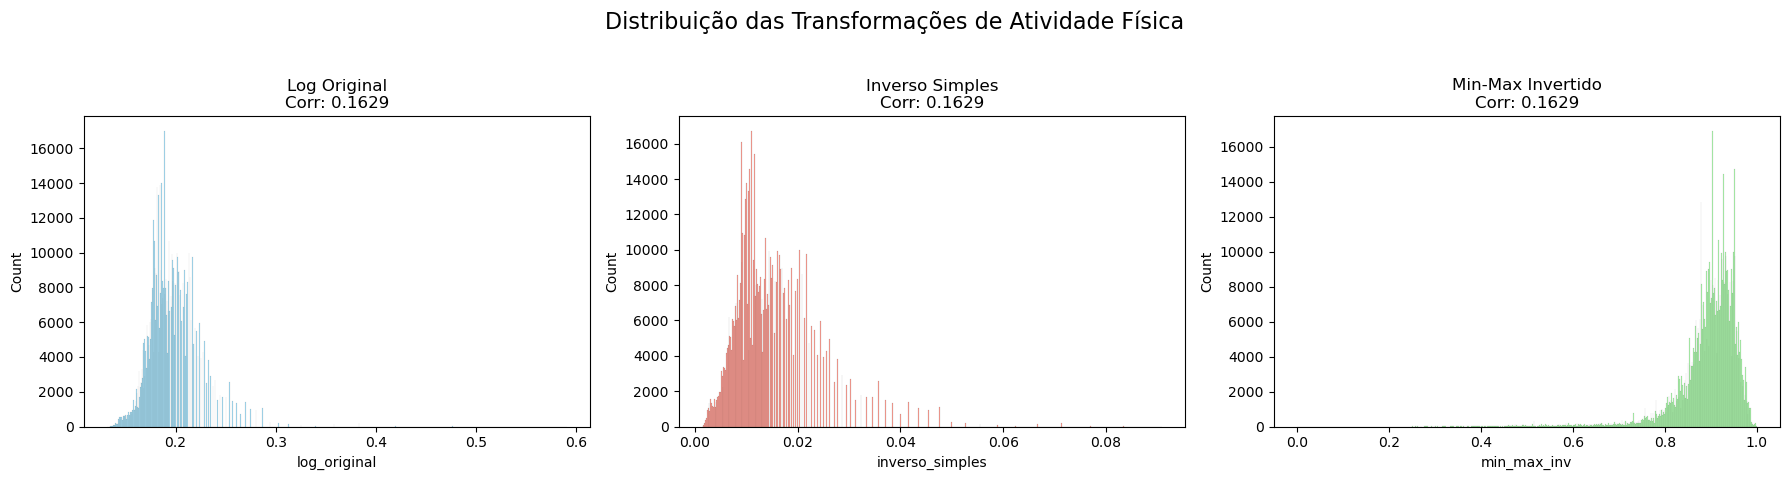

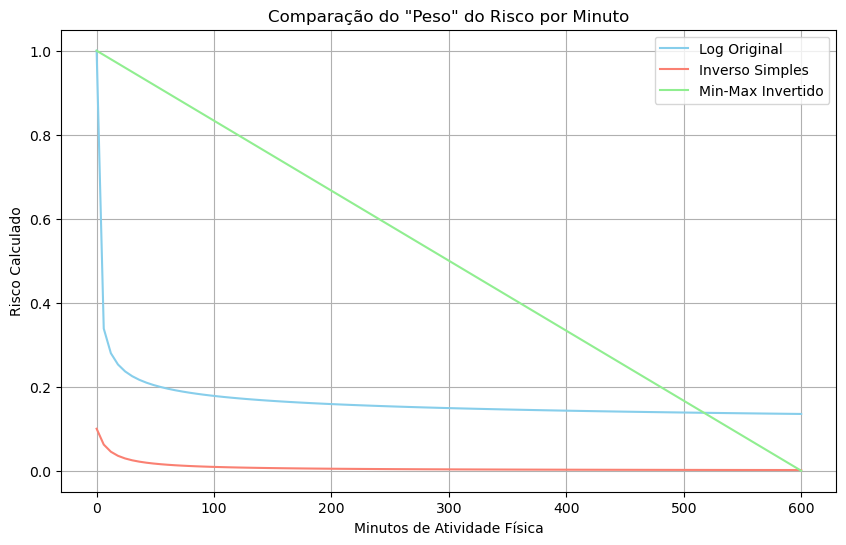

In [11]:
# Comparativo das transformações
df_filt['PAW'] = df_filt['physical_activity_minutes_per_week']
df_filt['log_original'] = 1 / (np.log1p(df_filt['PAW']) + 1)
df_filt['inverso_simples'] = 1 / (df_filt['PAW'] + 10)
df_filt['min_max_inv'] = 1 - ((df_filt['PAW'] - df_filt['PAW'].min()) / (df_filt['PAW'].max() - df_filt['PAW'].min()))

# Comparando correlações
correls = df_filt[['diagnosed_diabetes','PAW', 'log_original', 'inverso_simples', 'min_max_inv']].corr(method='spearman')['diagnosed_diabetes'].drop('diagnosed_diabetes')

largura = 70
print(f"{'='*largura}")
print(f"{'🧪 COMPARATIVO DE TRANSFORMÇÕES (CORRELAÇÃO)'.center(largura)}")
print(f"{'='*largura}")
for trans, val in correls.items():
    print(f" {trans:<20} | Correlação com Target: {val:>10.4f}")
print(f"{'='*largura}")


def bootstrap_corr(df, target_col, cols_to_test, n_iterations=100):
    results = {col: [] for col in cols_to_test}
    
    for _ in range(n_iterations):
        # Amostragem com reposição (Bootstrap)
        sample = df.sample(frac=1.0, replace=True)
        for col in cols_to_test:
            res = sample[[target_col, col]].corr(method='spearman').iloc[0, 1]
            results[col].append(res)
            
    return pd.DataFrame(results)

# Executando o teste
df_boot = bootstrap_corr(df_filt, 'diagnosed_diabetes', ['PAW','log_original', 'inverso_simples', 'min_max_inv'])

# Exibindo Estatísticas Descritivas
print(f"{'='*70}")
print(f"{'📊 ESTATÍSTICAS DE CORRELAÇÃO (BOOTSTRAP)'.center(70)}")
print(f"{'='*70}")
summary = df_boot.agg(['mean', 'std','median', 'min', 'max']).T
print(summary)
print(f"{'='*70}")


# Configuração da figura
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribuição das Transformações de Atividade Física', fontsize=16)

# 1. Log Original (Sua fórmula atual)
sns.histplot(df_filt['log_original'], ax=axes[0], color='skyblue')
axes[0].set_title(f'Log Original\nCorr: {correls["log_original"]:.4f}')

# 2. Inverso Simples (1 / x+10)
sns.histplot(df_filt['inverso_simples'], ax=axes[1], color='salmon')
axes[1].set_title(f'Inverso Simples\nCorr: {correls["inverso_simples"]:.4f}')

# 3. Min-Max Invertido (Linear)
sns.histplot(df_filt['min_max_inv'],ax=axes[2], color='lightgreen')
axes[2].set_title(f'Min-Max Invertido\nCorr: {correls["min_max_inv"]:.4f}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

test_val = np.linspace(0, 600, 100)
plt.figure(figsize=(10, 6))
plt.plot(test_val, 1 / (np.log1p(test_val) + 1), label='Log Original',color='skyblue')
plt.plot(test_val, 1 / (test_val + 10), label='Inverso Simples',color='salmon')
plt.plot(test_val, 1 - (test_val / 600), label='Min-Max Invertido',color='lightgreen')
plt.xlabel('Minutos de Atividade Física')
plt.ylabel('Risco Calculado')
plt.title('Comparação do "Peso" do Risco por Minuto')
plt.legend()
plt.grid(True)
plt.show()

# Removendo colunas temporarias da análise
df_filt=df_filt.drop(columns=['PAW','log_original','inverso_simples','min_max_inv'])

**Conclusão:** Não existe diferença entre as correlações das transformações aplicadas na variavel `physical_activity_minutes_per_week`